In [313]:
import pickle
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from joblib import Parallel, delayed

import states_config
from utils import decimal_to_str, exp_name_string_v2, exp_name_string_state_v2, exp_name_string_state_ql_pb
import run_omni_v2
importlib.reload(run_omni_v2)
from run_omni_v2 import omniprediction_multiq_online_v2

T = states_config.T
geo_big = states_config.geo_big
geo_med = states_config.geo_med
geo_small = states_config.geo_small
geo_list = states_config.geo_list

alpha_list = states_config.alpha_list
dates_list = states_config.dates_list
dates_list_pd = states_config.dates_list_pd

SAVE_DIR = states_config.SAVE_DIR_OMNI
SAVE_DIR_QL_PB = states_config.SAVE_DIR_QL_PB

eta_list = states_config.eta_list_omni
eta_list_ql = states_config.eta_list_ql

print(set(geo_big + geo_med + geo_small) - set(geo_list))
print(set(geo_list) - set(geo_big + geo_med + geo_small))

set()
{'US'}


In [4]:
%history -n -o -p

   1:
>>> import pickle
... import importlib
... 
... import numpy as np
... import pandas as pd
... import matplotlib.pyplot as plt
... from tqdm import tqdm
... from joblib import Parallel, delayed
... 
... import states_config
... from utils import decimal_to_str, exp_name_string_v2, exp_name_string_state_v2, exp_name_string_state_ql_pb
... import run_omni_v2
... importlib.reload(run_omni_v2)
... from run_omni_v2 import omniprediction_multiq_online_v2
... 
... T = states_config.T
... geo_big = states_config.geo_big
... geo_med = states_config.geo_med
... geo_small = states_config.geo_small
... geo_list = states_config.geo_list
... 
... alpha_list = states_config.alpha_list
... dates_list = states_config.dates_list
... dates_list_pd = states_config.dates_list_pd
... 
... SAVE_DIR = states_config.SAVE_DIR_OMNI
... SAVE_DIR_QL_PB = states_config.SAVE_DIR_QL_PB
... 
... eta_list = states_config.eta_list_omni
... eta_list_ql = states_config.eta_list_ql
... 
... print(set(geo_big + geo_me

# Smoothing outliers

In [5]:
impute_na = True

for geo in geo_big + geo_med + geo_small + ['US']:
    d = pickle.load(open(f'../data/hospitalizations/preprocess_states_weekly/{geo}{"" if impute_na else "_raw"}.pkl', 'rb'))
    f_list = d['forecaster_list']
    alpha_list = d['alpha_list']
    dates_list = d['dates_list']
    dates_list_pd = pd.to_datetime(dates_list)
    Y = d['Y']
    T = len(dates_list)

    ens_model_names = ['COVIDhub-4_week_ensemble', 'COVIDhub-trained_ensemble', 'JHUAPL-SLPHospEns']
    forecasts_wo_ens_dict = d['forecasts_dict']
    forecasts_ens_dict = {1: {}, 2: {}, 3: {}, 4: {}}
    f_list_wo_ens = [f for f in f_list if f not in ens_model_names]
    
    for w in range(1,5):
        for ens_f in ens_model_names:
            forecasts_ens_dict[w][ens_f] = forecasts_wo_ens_dict[w].pop(ens_f)

    # Outliers polishing
    # 'JHUAPL-Bucky' 'USC-SI_kJalpha' 'JHU_IDD-CovidSP' has a lot of BIG forecasts. 'MOBS-GLEAM_COVID' (only VT)
    def smooth_outliers(alpha_cut=0.9, cuts=None):
        alpha_cut_ix = np.where(np.array(alpha_list) == alpha_cut)[0][0]
        assert len(cuts) + alpha_cut_ix == len(alpha_list)
        for f_name in f_list_wo_ens:
            for ia in range(alpha_cut_ix, len(alpha_list)):
                ix = ia - alpha_cut_ix
                alpha = alpha_list[ia]
                if forecasts_wo_ens_dict[4][f_name][alpha].max() > cuts[ix]:
                    for w in range(1,5):
                        if ix == 0:
                            for alpha in alpha_list[:(ia+1)]:
                                forecasts_wo_ens_dict[w][f_name][alpha] = forecasts_wo_ens_dict[w][f_name][alpha].clip(upper=cuts[0])
                        else:
                            forecasts_wo_ens_dict[w][f_name][alpha] = forecasts_wo_ens_dict[w][f_name][alpha].clip(upper=cuts[ix])

    if geo == 'CA':
        smooth_outliers(alpha_cut=0.9, cuts=[110000, 120000, 125000, 130000])
    if geo == 'FL':
        smooth_outliers(alpha_cut=0.9, cuts=[80000, 90000, 100000, 121000])
    if geo == 'TX':
        smooth_outliers(alpha_cut=0.9, cuts=[90000, 100000, 120000, 135000])
    if geo == 'NY':
        smooth_outliers(alpha_cut=0.975, cuts=[80000, 85000])
    if geo == 'PA':
        smooth_outliers(alpha_cut=0.9, cuts=[35000, 40000, 50000, 55000])
    if geo == 'IL':
        smooth_outliers(alpha_cut=0.9, cuts=[25000, 30000, 31000, 35000])
    if geo == 'OH':
        smooth_outliers(alpha_cut=0.9, cuts=[35000, 40000, 45000, 55000])
    if geo == 'GA':
        smooth_outliers(alpha_cut=0.9, cuts=[43000, 45000, 49000, 50000])
    if geo == 'MI':
        smooth_outliers(alpha_cut=0.9, cuts=[30000, 35000, 45000, 50000])
    if geo == 'NJ':
        smooth_outliers(alpha_cut=0.975, cuts=[45000, 50000])
    if geo == 'VA':
        smooth_outliers(alpha_cut=0.99, cuts=[25000])
    if geo == 'WA':
        smooth_outliers(alpha_cut=0.95, cuts=[16000, 18000, 20000])
    if geo == 'TN':
        smooth_outliers(alpha_cut=0.95, cuts=[25000, 30000, 35000])
    if geo == 'MA':
        smooth_outliers(alpha_cut=0.95, cuts=[18000, 19000, 20000])
    if geo == 'IN':
        smooth_outliers(alpha_cut=0.975, cuts=[25000, 32000])
    if geo == 'MO':
        smooth_outliers(alpha_cut=0.95, cuts=[30000, 33000, 36000])
    if geo == 'MD':
        smooth_outliers(alpha_cut=0.9, cuts=[16000, 18000, 20000, 21000])
    if geo == 'CO':
        smooth_outliers(alpha_cut=0.9, cuts=[17000, 20000, 22000, 25000])
    if geo == 'WI':
        smooth_outliers(alpha_cut=0.9, cuts=[10000, 12000, 13000, 15000])
    if geo == 'MN':
        smooth_outliers(alpha_cut=0.9, cuts=[8000, 11000, 13000, 14000])
    if geo == 'SC':
        smooth_outliers(alpha_cut=0.9, cuts=[20000, 22000, 27000, 32000])
    if geo == 'AL':
        smooth_outliers(alpha_cut=0.975, cuts=[20000, 30000])
    if geo == 'LA':
        smooth_outliers(alpha_cut=0.975, cuts=[35000, 40000])
    if geo == 'OR':
        smooth_outliers(alpha_cut=0.9, cuts=[9000, 10000, 15000, 16000])
    if geo == 'OK':
        smooth_outliers(alpha_cut=0.99, cuts=[25000])
    if geo == 'CT':
        smooth_outliers(alpha_cut=0.99, cuts=[17000])
    if geo == 'UT':
        smooth_outliers(alpha_cut=0.975, cuts=[12000, 13000])
    if geo == 'NV':
        smooth_outliers(alpha_cut=0.99, cuts=[16000])
    if geo == 'IA':
        smooth_outliers(alpha_cut=0.9, cuts=[6000, 7000, 11000, 15000])
    if geo == 'AR':
        smooth_outliers(alpha_cut=0.9, cuts=[8000, 9000, 12500, 15000])
    if geo == 'KS':
        smooth_outliers(alpha_cut=0.975, cuts=[12000, 15000])
    if geo == 'NE':
        smooth_outliers(alpha_cut=0.975, cuts=[9000, 10000])
    if geo == 'NM':
        smooth_outliers(alpha_cut=0.9, cuts=[2500, 3000, 4000, 5000])
    if geo == 'ID':
        smooth_outliers(alpha_cut=0.975, cuts=[4500, 5500])
    if geo == 'NE':
        smooth_outliers(alpha_cut=0.95, cuts=[7000, 8500, 9000])
    if geo == 'WV':
        smooth_outliers(alpha_cut=0.975, cuts=[8000, 10000])
    if geo == 'HI':
        smooth_outliers(alpha_cut=0.99, cuts=[6000])
    if geo == 'ME':
        smooth_outliers(alpha_cut=0.9, cuts=[2700, 3800, 4200, 5000])
    if geo == 'MT':
        smooth_outliers(alpha_cut=0.9, cuts=[5000, 6000, 7000, 7500])
    if geo == 'DE':
        smooth_outliers(alpha_cut=0.9, cuts=[3000, 3500, 4000, 4500])
    if geo == 'SD':
        smooth_outliers(alpha_cut=0.975, cuts=[3000, 4000])
    if geo == 'ND':
        smooth_outliers(alpha_cut=0.9, cuts=[1500, 1700, 2000, 2500])
    if geo == 'AK':
        smooth_outliers(alpha_cut=0.9, cuts=[1500, 1700, 2000, 2200])
    if geo == 'DC':
        smooth_outliers(alpha_cut=0.9, cuts=[4500, 5000, 6000, 6500])
    if geo == 'VT':
        smooth_outliers(alpha_cut=0.9, cuts=[800, 900, 1000, 1100])
    if geo == 'WY':
        smooth_outliers(alpha_cut=0.975, cuts=[1300, 1500])
        
    if geo == 'US':
        smooth_outliers(alpha_cut=0.95, cuts=[900000, 910000, 920000])
        
    max_f = 0        
    for f_name in f_list_wo_ens:
        max_f = max(max_f, forecasts_wo_ens_dict[3][f_name][0.99].max())
    
    # print(f_list)
    # print(forecasts_wo_ens_dict[w].keys())
    # print(alpha_list)
    
    print(geo, f'max_f: {max_f:<6.0f}', f'max_y: {Y.max():<6.0f}', f'r: {max_f/Y.max():<6.2f}', dates_list[:2], dates_list[-2:], )
    
    new_d = {}
    new_d['forecaster_list'] = f_list_wo_ens
    new_d['alpha_list'] = alpha_list
    new_d['dates_list'] = dates_list
    new_d['Y'] = Y
    if geo == 'US':
        unit = 500
    elif geo in ['CA', 'TX', 'FL', 'NY']:
        unit = 100
    elif geo in ['PA', 'IL', 'OH', 'GA', 'NC', 'MI', 'NJ']:
        unit = 50
    elif geo in ['VA', 'WA', 'AZ', 'TN', 'MA', 'IN', 'MO', 'MD', 'CO', 'WI', 'MN', 'SC', 'AL', 'LA', 'KY', 'OK', 'CT', 'AR']:
        unit = 20
    elif geo in ['OR', 'UT', 'NV', 'IA', 'KS', 'MS', 'MT', 'DC']:
        unit = 10
    elif geo in ['NM', 'ID', 'NE', 'WV', 'HI', 'NH', 'ME', 'DE', 'SD']:
        unit = 5
    elif geo in ['RI', 'ND', 'AK', 'VT', 'WY']:
        unit = 2
    else:
        print(geo)
    
    new_d['unit'] = unit
    new_d['forecasts_dict'] = forecasts_wo_ens_dict
    new_d['forecasts_ens_dict'] = forecasts_ens_dict
    pickle.dump(new_d, open(f'../data/hospitalizations/preprocess_states_weekly_trimmed/{geo}{"" if impute_na else "_raw"}.pkl', 'wb'))

CA max_f: 130000 max_y: 16343  r: 7.95   Index(['2020-12-29', '2021-01-05'], dtype='str') Index(['2023-05-23', '2023-05-30'], dtype='str')
TX max_f: 135000 max_y: 14544  r: 9.28   Index(['2020-12-29', '2021-01-05'], dtype='str') Index(['2023-05-23', '2023-05-30'], dtype='str')
FL max_f: 148421 max_y: 15772  r: 9.41   Index(['2020-12-29', '2021-01-05'], dtype='str') Index(['2023-05-23', '2023-05-30'], dtype='str')
NY max_f: 85000  max_y: 11967  r: 7.10   Index(['2020-12-29', '2021-01-05'], dtype='str') Index(['2023-05-23', '2023-05-30'], dtype='str')
PA max_f: 55000  max_y: 6380   r: 8.62   Index(['2020-12-29', '2021-01-05'], dtype='str') Index(['2023-05-23', '2023-05-30'], dtype='str')
IL max_f: 35000  max_y: 6403   r: 5.47   Index(['2020-12-29', '2021-01-05'], dtype='str') Index(['2023-05-23', '2023-05-30'], dtype='str')
OH max_f: 73077  max_y: 7252   r: 10.08  Index(['2020-12-29', '2021-01-05'], dtype='str') Index(['2023-05-23', '2023-05-30'], dtype='str')
GA max_f: 50000  max_y: 596

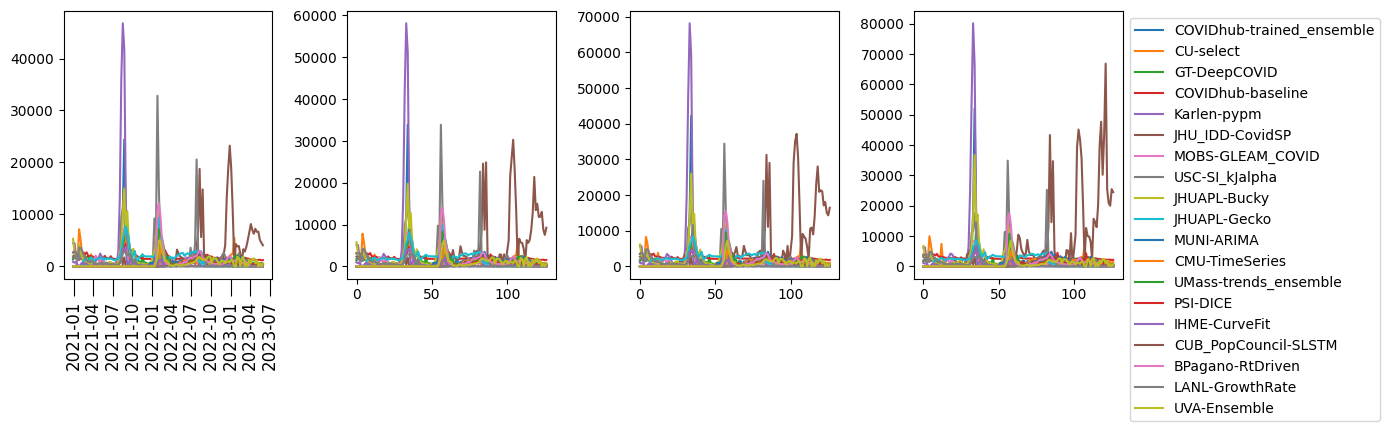

In [ ]:
geo = 'LA'
w = 4

d = pickle.load(open(f'../data/hospitalizations/preprocess_states_weekly/{geo}.pkl', 'rb'))
f_list = d['forecaster_list']
alpha_list = d['alpha_list']
dates_list = d['dates_list']
dates_list_pd = pd.to_datetime(dates_list)
Y = d['Y']
T = len(dates_list)

ens_model_names = ['COVIDhub-4_week_ensemble', 'JHUAPL-SLPHospEns']
forecasts_wo_ens_dict = d['forecasts_dict']
f_list_wo_ens = [f for f in f_list if f not in ens_model_names]

fig, ax = plt.subplots(1, 4, figsize=(14, 4))
for f_name in f_list_wo_ens:
    # if f_name == 'JHUAPL-Bucky': continue
    # if f_name == 'JHU_IDD-CovidSP': continue
    # if f_name == 'USC-SI_kJalpha': continue
    ax[0].plot(dates_list_pd, forecasts_wo_ens_dict[w][f_name][0.9], label=f_name)
    ax[1].plot(np.arange(T), forecasts_wo_ens_dict[w][f_name][0.95], label=f_name)
    ax[2].plot(np.arange(T), forecasts_wo_ens_dict[w][f_name][0.975], label=f_name)
    ax[3].plot(np.arange(T), forecasts_wo_ens_dict[w][f_name][0.99], label=f_name)
ax[0].tick_params(axis='x', labelrotation=90, labelsize=12, size=12)
ax[3].legend(bbox_to_anchor=(1, 1))
# ax[0].set_ylim(0, 2500)
fig.tight_layout()
plt.show()

In [212]:
for alpha in alpha_list[-5:]:
    # print(forecasts_wo_ens_dict[w]['JHUAPL-Bucky'][alpha].iloc[55:60].round(0)) # US
    print(dates_list_pd[np.where(forecasts_wo_ens_dict[w]['JHUAPL-Bucky'][alpha] > 25000)]) # IL

DatetimeIndex(['2022-01-18', '2022-01-25', '2022-02-01'], dtype='datetime64[us]', freq=None)
DatetimeIndex(['2022-01-11', '2022-01-18', '2022-01-25', '2022-02-01'], dtype='datetime64[us]', freq=None)
DatetimeIndex(['2022-01-11', '2022-01-18', '2022-01-25', '2022-02-01'], dtype='datetime64[us]', freq=None)
DatetimeIndex(['2022-01-11', '2022-01-18', '2022-01-25', '2022-02-01'], dtype='datetime64[us]', freq=None)
DatetimeIndex(['2022-01-11', '2022-01-18', '2022-01-25', '2022-02-01',
               '2022-02-08'],
              dtype='datetime64[us]', freq=None)


# Base forecasters info

In [7]:
# Parallelized over (geo, w)
impute_na = True


def process_geo(geo, impute_na=True, round_Y_F=True):
    d = pickle.load(open(f'../data/hospitalizations/preprocess_states_weekly_trimmed/{geo}{"" if impute_na else "_raw"}.pkl', 'rb'))
    alpha_list_local = d['alpha_list']
    dates_list_local = d['dates_list']
    Y = d['Y']
    unit = d['unit']
    T = len(dates_list_local)

    ens_model_names = ['COVIDhub-4_week_ensemble', 'COVIDhub-trained_ensemble', 'JHUAPL-SLPHospEns']

    for w in range(1,5):
        forecasts_dict = d['forecasts_dict'][w]
        ens_dict = d['forecasts_ens_dict'][w]

        forecast_min = np.inf
        forecast_max = -np.inf
        for _, forecast_dic in forecasts_dict.items():
            forecast_min = min(forecast_min, forecast_dic[min(alpha_list_local)].min())
            forecast_max = max(forecast_max, forecast_dic[max(alpha_list_local)].max())

        Y_rounded_min = min(int(np.floor(forecast_min / unit)), 0)
        Y_rounded_max = int(np.ceil(forecast_max / unit))
        m = Y_rounded_max - Y_rounded_min
        thetas = np.arange(Y_rounded_min, Y_rounded_max) + 0.5

        F = len(forecasts_dict.keys())
        forecaster_names = list(forecasts_dict.keys())

        alpha_list_local = np.array(alpha_list_local)
        N = alpha_list_local.shape[0]

        for forecaster in forecaster_names:
            for alpha in alpha_list_local:
                if alpha not in forecasts_dict[forecaster].keys():
                    raise ValueError(f"alpha {alpha} not in forecasts_dict[{forecaster}].keys()")
                assert set(forecasts_dict[forecaster][alpha].index) == set(Y.index)

        if round_Y_F:
            Y = (d['Y'] / unit).round(decimals=0).copy()
            Y_orig = d['Y'].copy()
        else:
            Y = (d['Y'] / unit).copy()
            Y_orig = d['Y'].copy()

        forecasts_dict_unit = {}
        forecasts_dict_orig = {}
        ens_dict_unit = {}
        ens_dict_orig = {}

        for forecaster in forecaster_names:
            forecasts_dict_unit[forecaster] = {}
            forecasts_dict_orig[forecaster] = {}
            for alpha in alpha_list_local:
                if round_Y_F:
                    forecasts_dict_unit[forecaster][alpha] = (forecasts_dict[forecaster][alpha] / unit).round(decimals=0)
                    forecasts_dict_orig[forecaster][alpha] = forecasts_dict[forecaster][alpha]
                else:
                    forecasts_dict_unit[forecaster][alpha] = forecasts_dict[forecaster][alpha] / unit

        for ens_f in ens_model_names:
            ens_dict_unit[ens_f] = {}
            ens_dict_orig[ens_f] = {}
            for alpha in alpha_list_local:
                if round_Y_F:
                    ens_dict_unit[ens_f][alpha] = (ens_dict[ens_f][alpha] / unit).round(decimals=0)
                    ens_dict_orig[ens_f][alpha] = ens_dict[ens_f][alpha]
                else:
                    ens_dict_unit[ens_f][alpha] = ens_dict[ens_f][alpha] / unit

        def forecasts_dict_to_all_forecaster_preds_all_dates(f_dict, f_names):
            return np.stack([
                np.stack([f_dict[f][a].loc[dates_list_local].to_numpy() for a in alpha_list_local], axis=1)
                for f in f_names
            ], axis=-1)

        all_forecaster_preds_all_dates = forecasts_dict_to_all_forecaster_preds_all_dates(forecasts_dict_unit, forecaster_names)
        all_forecaster_preds_all_dates_orig = forecasts_dict_to_all_forecaster_preds_all_dates(forecasts_dict_orig, forecaster_names)
        all_ens_preds_all_dates = forecasts_dict_to_all_forecaster_preds_all_dates(ens_dict_unit, ens_model_names)
        all_ens_preds_all_dates_orig = forecasts_dict_to_all_forecaster_preds_all_dates(ens_dict_orig, ens_model_names)

        from run_omni_v2 import omni_error_from_scores
        from metrics import elementary_scores_grid_N_F, pinball_loss, ql_error_from_pb_loss

        forecasters_score_history = np.zeros((T, N, m, F))
        forecasters_pb_loss_history = np.zeros((T, N, F))
        ens_score_history = np.zeros((T, N, m, len(ens_model_names)))
        ens_pb_loss_history = np.zeros((T, N, len(ens_model_names)))
        for t, date in enumerate(dates_list_local):
            y_t = Y[date]
            f_scores = elementary_scores_grid_N_F(all_forecaster_preds_all_dates[t, :, :], y_t, thetas, alpha_list_local)
            forecasters_score_history[t, :, :, :] = f_scores
            forecasters_pb_loss_history[t, :, :] = pinball_loss(all_forecaster_preds_all_dates[t, :, :], y_t, alpha_list_local[:, None]) / m

            ens_scores = elementary_scores_grid_N_F(all_ens_preds_all_dates[t, :, :], y_t, thetas, alpha_list_local)
            ens_score_history[t, :, :, :] = ens_scores
            ens_pb_loss_history[t, :, :] = pinball_loss(all_ens_preds_all_dates[t, :, :], y_t, alpha_list_local[:, None]) / m

        forecasters_score_trace = omni_error_from_scores(forecasters_score_history)
        best_forecaster_score_trace = forecasters_score_trace.min(axis=1)
        forecasters_pb_loss_trace = ql_error_from_pb_loss(forecasters_pb_loss_history)
        best_forecaster_pb_loss_trace = forecasters_pb_loss_trace.min(axis=1)

        ens_score_trace = omni_error_from_scores(ens_score_history)
        ens_pb_loss_trace = ql_error_from_pb_loss(ens_pb_loss_history)

        f_dic = {
            'geo': geo,
            'w': w,
            'round_Y_F': round_Y_F,
            'Y': Y,
            'unit': unit,
            'T': T,
            'N': N,
            'm': m,
            'F': F,
            'dates_list': dates_list_local,
            'alpha_list': alpha_list_local,
            'Y_orig': Y_orig,
            'forecasters_preds_history_orig': all_forecaster_preds_all_dates_orig,
            'ens_preds_history_orig': all_ens_preds_all_dates_orig,
            'forecaster_names': forecaster_names,
            'ens_model_names': ens_model_names,
            'forecasts_dict': forecasts_dict_unit,
            'ens_dict': ens_dict_unit,
            'forecasters_preds_history': all_forecaster_preds_all_dates,
            'forecasters_score_trace': forecasters_score_trace,
            'best_forecaster_score_trace': best_forecaster_score_trace,
            'forecasters_pb_loss_history': forecasters_pb_loss_history,
            'forecasters_pb_loss_trace': forecasters_pb_loss_trace,
            'best_forecaster_pb_loss_trace': best_forecaster_pb_loss_trace,
            'ens_score_trace': ens_score_trace,
            'ens_pb_loss_history': ens_pb_loss_history,
            'ens_pb_loss_trace': ens_pb_loss_trace,
        }
        pickle.dump(
            f_dic,
            open(
                f'../data/hospitalizations/preprocess_states_weekly_trimmed/wk{w}_{geo}{"" if impute_na else "_raw"}_baseforecasters{"" if round_Y_F else "_orig"}.pkl',
                'wb',
            ),
        )

jobs = geo_list
print(f"Total jobs: {len(jobs)}")

Parallel(n_jobs=-1, verbose=10)(
    delayed(process_geo)(geo, impute_na=impute_na, round_Y_F=True)
    for geo in jobs
)

Total jobs: 52


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:   13.3s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:   29.7s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:   53.8s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:  1.8min
/Users/hyunsuk/projects/omni-quantile/.venv/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
[Parallel(n_jobs=-1)]: Done  43 out of  52 | elapsed:  2.1min remaining:   26.9s
[Parallel(n_jobs=-1)]: Done  49 out of  52 | elapsed:  2.3min remaining:    8.4s
[Parallel(n_jobs=-1)]: Done  52 out of  52 | elapsed:  2.3min finished


[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

In [3]:
impute_na = True

for geo in tqdm(geo_big + geo_med + geo_small + ['US']):
    d = pickle.load(open(f'../data/hospitalizations/preprocess_states_weekly_trimmed/{geo}{"" if impute_na else "_raw"}.pkl', 'rb'))
    f_list = d['forecaster_list']
    alpha_list = d['alpha_list']
    dates_list = d['dates_list']
    dates_list_pd = pd.to_datetime(dates_list)
    Y = d['Y']
    unit = d['unit']
    T = len(dates_list)

    ens_model_names = ['COVIDhub-4_week_ensemble', 'COVIDhub-trained_ensemble', 'JHUAPL-SLPHospEns']
    forecasts_dict_allw = d['forecasts_dict']
    ens_dict_allw = d['forecasts_ens_dict']
    
    for w in range(1,5):
        for round_Y_F in [True]:
            forecasts_dict = forecasts_dict_allw[w]
            ens_dict = ens_dict_allw[w]
            # Setting up the range of Y and discretized thetas
            forecast_min = np.inf
            forecast_max = -np.inf
            for f_name, forecast_dic in forecasts_dict.items():
                forecast_min = min(forecast_min, forecast_dic[min(alpha_list)].min())
                forecast_max = max(forecast_max, forecast_dic[max(alpha_list)].max())

            Y_rounded_min = min(int(np.floor(forecast_min / unit)), 0)
            Y_rounded_max = int(np.ceil(forecast_max / unit))
            m = Y_rounded_max - Y_rounded_min
            thetas = np.arange(Y_rounded_min, Y_rounded_max) + 0.5

            F = len(forecasts_dict.keys())
            forecaster_names = list(forecasts_dict.keys())

            alpha_list = np.array(alpha_list)
            assert len(alpha_list.shape) == 1
            N = alpha_list.shape[0]

            for forecaster in forecaster_names:
                for alpha in alpha_list:
                    if alpha not in forecasts_dict[forecaster].keys():
                        raise ValueError(f"alpha {alpha} not in forecasts_dict[{forecaster}].keys()")
                    assert set(forecasts_dict[forecaster][alpha].index) == set(Y.index), f'forecasts_dict[forecaster][alpha].index: {forecasts_dict[forecaster][alpha].index}, Y.index: {Y.index}'

            if round_Y_F:
                Y = (d['Y']/unit).round(decimals=0).copy()
                Y_orig = d['Y'].copy()
            else:
                Y = (d['Y']/unit).copy()
            
            
            forecasts_dict_unit = {}
            forecasts_dict_orig = {}
            ens_dict_unit = {}
            ens_dict_orig = {}
            
            for forecaster in forecaster_names:
                forecasts_dict_unit[forecaster] = {}
                forecasts_dict_orig[forecaster] = {}
                for alpha in alpha_list:
                    if round_Y_F:
                        forecasts_dict_unit[forecaster][alpha] = (forecasts_dict[forecaster][alpha] / unit).round(decimals=0)
                        forecasts_dict_orig[forecaster][alpha] = forecasts_dict[forecaster][alpha]
                    else:
                        forecasts_dict_unit[forecaster][alpha] = forecasts_dict[forecaster][alpha] / unit

            for ens_f in ens_model_names:
                ens_dict_unit[ens_f] = {}
                ens_dict_orig[ens_f] = {}
                for alpha in alpha_list:
                    if round_Y_F:
                        ens_dict_unit[ens_f][alpha] = (ens_dict[ens_f][alpha] / unit).round(decimals=0)
                        ens_dict_orig[ens_f][alpha] = ens_dict[ens_f][alpha]
                    else:
                        ens_dict_unit[ens_f][alpha] = ens_dict[ens_f][alpha] / unit
                    
            def forecasts_dict_to_all_forecaster_preds_all_dates(f_dict, f_names):
                return np.stack([
                    np.stack([f_dict[f][a].loc[dates_list].to_numpy() for a in alpha_list], axis=1)
                    for f in f_names
                    ], axis=-1)
            
            all_forecaster_preds_all_dates = forecasts_dict_to_all_forecaster_preds_all_dates(forecasts_dict_unit, forecaster_names)
            all_forecaster_preds_all_dates_orig = forecasts_dict_to_all_forecaster_preds_all_dates(forecasts_dict_orig, forecaster_names)
            all_ens_preds_all_dates = forecasts_dict_to_all_forecaster_preds_all_dates(ens_dict_unit, ens_model_names)
            all_ens_preds_all_dates_orig = forecasts_dict_to_all_forecaster_preds_all_dates(ens_dict_orig, ens_model_names)
            

            from run_omni_v2 import omni_error_from_scores
            from metrics import elementary_scores_grid_N_F, pinball_loss, ql_error_from_pb_loss

            forecasters_score_history = np.zeros((T, N, m, F))
            forecasters_pb_loss_history = np.zeros((T, N, F))
            ens_score_history = np.zeros((T, N, m, len(ens_model_names)))
            ens_pb_loss_history = np.zeros((T, N, len(ens_model_names)))
            for t, date in enumerate(dates_list):
                y_t = Y[date]
                f_scores = elementary_scores_grid_N_F(all_forecaster_preds_all_dates[t,:,:], y_t, thetas, alpha_list)
                forecasters_score_history[t,:,:,:] = f_scores    
                forecasters_pb_loss_history[t,:,:] = pinball_loss(all_forecaster_preds_all_dates[t,:,:], y_t, alpha_list[:, None]) / m

                ens_scores = elementary_scores_grid_N_F(all_ens_preds_all_dates[t,:,:], y_t, thetas, alpha_list)
                ens_score_history[t,:,:,:] = ens_scores
                ens_pb_loss_history[t,:,:] = pinball_loss(all_ens_preds_all_dates[t,:,:], y_t, alpha_list[:, None]) / m
                
            forecasters_score_trace = omni_error_from_scores(forecasters_score_history)
            best_forecaster_score_trace = forecasters_score_trace.min(axis=1)
            forecasters_pb_loss_trace = ql_error_from_pb_loss(forecasters_pb_loss_history)
            best_forecaster_pb_loss_trace = forecasters_pb_loss_trace.min(axis=1)

            ens_score_trace = omni_error_from_scores(ens_score_history)
            ens_pb_loss_trace = ql_error_from_pb_loss(ens_pb_loss_history)

            f_dic = {
                'geo': geo,
                'w': w,
                'round_Y_F': round_Y_F,
                
                'Y': Y,
                'unit': unit,
                'T': T,
                'N': N,
                'm': m,
                'F': F,
                'dates_list': dates_list,
                'alpha_list': alpha_list,

                'Y_orig': Y_orig,
                'forecasters_preds_history_orig': all_forecaster_preds_all_dates_orig,
                'ens_preds_history_orig': all_ens_preds_all_dates_orig,

                'forecaster_names': forecaster_names,
                'ens_model_names': ens_model_names,
                'forecasts_dict': forecasts_dict_unit,
                'ens_dict': ens_dict_unit,

                'forecasters_preds_history': all_forecaster_preds_all_dates,
                # 'forecasters_score_history': forecasters_score_history,
                'ens_preds_history': all_ens_preds_all_dates,
                # 'ens_score_history': ens_score_history,

                'forecasters_score_trace': forecasters_score_trace,
                'best_forecaster_score_trace': best_forecaster_score_trace,
                'forecasters_pb_loss_history': forecasters_pb_loss_history,
                'forecasters_pb_loss_trace': forecasters_pb_loss_trace,
                'best_forecaster_pb_loss_trace': best_forecaster_pb_loss_trace,

                'ens_score_trace': ens_score_trace,
                'ens_pb_loss_history': ens_pb_loss_history,
                'ens_pb_loss_trace': ens_pb_loss_trace,
            }
            pickle.dump(f_dic, open(f'../data/hospitalizations/preprocess_states_weekly_trimmed/wk{w}_{geo}{"" if impute_na else "_raw"}_baseforecasters{"" if round_Y_F else "_orig"}.pkl', 'wb'))

100%|██████████| 52/52 [03:39<00:00,  4.22s/it]


# Main run

In [ ]:
from joblib import Parallel, delayed
import os

geo_list_here = geo_big + geo_med + geo_small + ['US'] + 
suffix_here = '_new'

def run_one(geo, w, eta_multiplier):
    try:
        d = pickle.load(open(f'../data/hospitalizations/preprocess_states_weekly_trimmed/{geo}.pkl', 'rb'))
        results = omniprediction_multiq_online_v2(
            Y=d['Y'][d['dates_list']],
            forecasts_dict=d['forecasts_dict'][w],
            unit=d['unit'],
            alpha_list=d['alpha_list'],
            eta_multiplier=eta_multiplier,
            verbose=False,
        )
        exp_name = exp_name_string_state_v2(w, geo, eta_multiplier, suffix=suffix_here)
        pickle.dump(results, open(f"{SAVE_DIR}/results_{exp_name}.pkl", 'wb'))
        return {'ok': True, 'geo': geo, 'w': w, 'eta': eta_multiplier, 'result': results}
    except Exception as e:
        print(f'{geo} {w} {eta_multiplier} failed')
        print(e)
        return {'ok': False, 'geo': geo, 'w': w, 'eta': eta_multiplier}

jobs = [(geo, w, eta) 
        for geo in geo_list_here
        for w in range(1, 5)
        for eta in eta_list
        ]
        # if not os.path.exists(f"{SAVE_DIR}/results_{exp_name_string_state_v2(w, geo, eta, suffix=suffix_here)}.pkl")]

print(f"Total jobs: {len(jobs)}")

all_results = Parallel(n_jobs=-1, backend='loky', verbose=10)(
    delayed(run_one)(geo, w, eta) for geo, w, eta in jobs
)

Total jobs: 300


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    5.2s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    8.1s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:   10.8s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:   16.8s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   22.5s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:   28.8s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:   37.1s
[Parallel(n_jobs=-1)]: Done  69 tasks      | elapsed:   46.1s
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:   52.9s
[Parallel(n_jobs=-1)]: Done  97 tasks      | elapsed:  1.0min
[Parallel(n_jobs=-1)]: Done 112 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 129 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 165 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:  1